# **AIN 214 - PA2 - FALL 2025**

**Student Number** : 2230765012

**Name Surname**   : Koray Solakoğlu


BELOW MD CELLS CONTAIN THE QUESTIONS YOU ARE ASKED TO IMPLEMENT WITHIN THE CONTEXT OF THIS HW. PLEASE FILL IN THE CELLS FOR THE ANSWERS RIGHT BELOW THE MD CELL OF THE QUESTION. YOU CAN ADD AS MANY CELLS AS YOU WANT, BE IT CODE OR MD, SO LONG AS YOU PROVIDE UNDERSTANDABLE AND TRACEABLE REPORTING. PLEASE ADD COMMENTS ON YOUR CODES. ALSO, FILL IN MD CELLS WHERE YOU ARE ASKED TO COMMENT ON YOUR RESULTS OR EXPLAIN YOUR REASONING. ALSO, PLEASE DO NOT HESITATE TO USE THEM FOR YOUR OWN REPORTING PURPOSES. PLEASE KEEP IN MIND THAT, REPORTING IS A KEY STEP IN DATA SCIENCE.

**Deadline: 24.11.2025 (23:59:59)**

**Submission:** Submit your Jupyter Notebooks via https://submit.cs.hacettepe.edu.tr/

<font color='red'> **!!! PLEASE RUN YOUR CODE.   THE OUTPUT OF YOUR CODE MUST BE VISIBLE. DO NOT DELETE OR HIDE THE OUTPUT.**</font>

# **Necessary Imports**

In [1]:
# Import required python modules
import pandas as pd
import sqlite3

# **PART- 1**

**Superstore Sales Management System (50 Points)**



For this part, you will use a dataset from a Superstore retail company. The dataset includes comprehensive information about customers, products, orders, and sales operations across different regions in the United States.

**Dataset Entities**

* **Customers**: The system contains detailed customer profiles including customer ID, name, and segment information (Consumer, Corporate, Home Office). Understanding customer demographics and purchasing behavior is essential for targeted marketing and customer relationship management.

* **Products**: A comprehensive catalog of all products sold by the superstore. Each product record includes a unique product ID, product name, category (Furniture, Office Supplies, Technology), and sub-category. This information is crucial for inventory management, product performance analysis, and strategic planning.

* **Locations**: Geographic information about where customers are located and where orders are shipped. Includes city, state, postal code, region (Central, East, South, West), and country. This data enables regional sales analysis and helps optimize distribution and shipping strategies.

* **Orders**: Tracks all purchase transactions made by customers. Each order contains the order date, ship date, shipping mode (Standard Class, Second Class, First Class, Same Day), and links to customer and location information. This serves as the foundation for analyzing sales trends, shipping efficiency, and customer purchasing patterns.

* **Order Details**:  Detailed line items for each order, recording which products were purchased, quantity, sales amount, discount applied, and profit generated. This granular data is essential for profitability analysis, discount impact assessment, and understanding product performance at the transaction level.


This dataset will be used to design a normalized relational database for managing retail operations. Your task is to build an efficient database schema, establish proper relationships between tables, and write SQL queries to extract meaningful business insights.


**Dataset Columns**

* **Row ID**: Unique identifier for each row in the dataset (sequential number)
* **Order ID**: Unique identifier for each order (format: XX-YYYY-NNNNNN). Multiple rows can have the same Order ID if the order contains multiple products
* **Order Date**: Date when the order was placed by the customer (format: MM/DD/YYYY)
* **Ship Date**: Date when the order was shipped to the customer (format: MM/DD/YYYY)
* **Ship Mode**: Shipping method selected for the order (Standard Class, Second Class, First Class, Same Day)
* **Customer ID**: Unique identifier for each customer (format: XX-NNNNN)
* **Customer Name**: Full name of the customer who placed the order
* **Segment**: Customer segment classification (Consumer, Corporate, Home Office)
* **Country**: Country where the customer is located (all orders are from United States)
* **City**: City name where the order is being shipped
* **State**: US state where the order is being shipped (2-letter state code)
* **Postal Code**: ZIP code of the delivery location (5-digit postal code)
* **Region**: Geographic region classification (Central, East, South, West)
* **Product ID**: Unique identifier for each product (format: XXX-XX-NNNNNNN)
* **Category**: High-level product category (Furniture, Office Supplies, Technology)
* **Sub-Category**: Detailed product classification within the category (e.g., Chairs, Phones, Binders)
* **Product Name**: Full descriptive name of the product
* **Sales**: Revenue generated from the product sale in US Dollars ($)
* **Quantity**: Number of units of the product purchased in the order
* **Discount**: Discount rate applied to the product (decimal value between 0 and 1, where 0.2 = 20% discount)
* **Profit**: Profit earned from the sale after deducting costs and discounts in US Dollars ($). Can be negative if the sale resulted in a loss

---


**Dataset Path:** "Data/Sample - Superstore.csv"
  
---

**Technical Requirements**
* **Databas**: Use sqlite3 Python package for in-memory database management
* **Libraries**: Use pandas for data manipulation

**Note** You can use either pandas or sqlite3 for query execution.

---
**Notes on Database Implementation**

All database operations should be performed in-memory using SQLite. This means:
* Database exists only during program execution
* No persistent file is created
* Fast performance for analysis tasks
* Connection should remain open throughout all questions

---

### Q1. Design your schema as tables. Draw the necessary tables with the appropriate attributes. State the primary keys, foreign keys (and their references). Create the tables in your schema in the database(10pts).

Your database design here
---
---
***Example Table***:


| Column   | Type  | Key      | Description                              |
|----------|-------|----------|------------------------------------------|
| ID       | INTEGER| PK      | Unique identifier table1                 |
| ID2      | INTEGER| FK      | identifier table2                        |
| Name     | TEXT   |         | patient name                             |
| FOREIGN KEY (ID2) REFERENCES table2(ID2)     |    |          |         |

### Database Schema Design

Below is the normalized database schema design for the Superstore dataset.

#### 1. Customers Table
Stores unique customer information.

| Column        | Type    | Key | Description                                      |
|---------------|---------|-----|--------------------------------------------------|
| Customer ID   | TEXT    | PK  | Unique identifier for the customer               |
| Customer Name | TEXT    |     | Full name of the customer                        |
| Segment       | TEXT    |     | Customer segment (Consumer, Corporate, etc.)     |

---

#### 2. Locations Table
Stores geographic location details.

| Column      | Type    | Key | Description                                      |
|-------------|---------|-----|--------------------------------------------------|
| Postal Code | INTEGER | PK  | Zip code (Acts as unique ID for location)        |
| Country     | TEXT    |     | Country name                                     |
| City        | TEXT    |     | City name                                        |
| State       | TEXT    |     | State name                                       |
| Region      | TEXT    |     | Region (East, West, etc.)                        |

---

#### 3. Products Table
Stores product catalog information.

| Column       | Type    | Key | Description                                      |
|--------------|---------|-----|--------------------------------------------------|
| Product ID   | TEXT    | PK  | Unique identifier for the product                |
| Category     | TEXT    |     | Main category (Furniture, Technology, etc.)      |
| Sub-Category | TEXT    |     | Sub-category of the product                      |
| Product Name | TEXT    |     | Full name of the product                         |

---

#### 4. Orders Table
Stores order header information (Who bought what, when, and where to).

| Column      | Type    | Key | Description                                      |
|-------------|---------|-----|--------------------------------------------------|
| Order ID    | TEXT    | PK  | Unique identifier for the order                  |
| Order Date  | DATE    |     | Date the order was placed                        |
| Ship Date   | DATE    |     | Date the order was shipped                       |
| Ship Mode   | TEXT    |     | Mode of shipment                                 |
| Customer ID | TEXT    | FK  | References **Customers(Customer ID)** |
| Postal Code | INTEGER | FK  | References **Locations(Postal Code)** |

---

#### 5. OrderDetails Table
Stores line items for each order (Transactions).

| Column     | Type    | Key | Description                                      |
|------------|---------|-----|--------------------------------------------------|
| Row ID     | INTEGER | PK  | Unique identifier for each row/transaction       |
| Order ID   | TEXT    | FK  | References **Orders(Order ID)** |
| Product ID | TEXT    | FK  | References **Products(Product ID)** |
| Sales      | REAL    |     | Sales amount                                     |
| Quantity   | INTEGER |     | Number of units sold                             |
| Discount   | REAL    |     | Discount percentage                              |
| Profit     | REAL    |     | Profit amount                                    |

In [2]:
try:
    df = pd.read_csv("Data/Sample - Superstore.csv", encoding='ISO-8859-1')
except FileNotFoundError:
    try:
        df = pd.read_csv("Sample - Superstore.csv", encoding='ISO-8859-1')
    except FileNotFoundError:
        print("Error: File not found. Please check the file path.")

conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

customers_df = df[['Customer ID', 'Customer Name', 'Segment']].drop_duplicates()
customers_df.to_sql('Customers', conn, index=False, if_exists='replace')

locations_df = df[['Postal Code', 'Country', 'City', 'State', 'Region']].drop_duplicates()
locations_df.to_sql('Locations', conn, index=False, if_exists='replace')

products_df = df[['Product ID', 'Category', 'Sub-Category', 'Product Name']].drop_duplicates()
products_df.to_sql('Products', conn, index=False, if_exists='replace')

orders_df = df[['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Postal Code']].drop_duplicates()
orders_df.to_sql('Orders', conn, index=False, if_exists='replace')

details_df = df[['Row ID', 'Order ID', 'Product ID', 'Sales', 'Quantity', 'Discount', 'Profit']]
details_df.to_sql('OrderDetails', conn, index=False, if_exists='replace')

print("Tables created successfully.")
print(f"Customers: {len(customers_df)}")
print(f"Locations: {len(locations_df)}")
print(f"Products: {len(products_df)}")
print(f"Orders: {len(orders_df)}")
print(f"OrderDetails: {len(details_df)}")

Tables created successfully.
Customers: 793
Locations: 632
Products: 1894
Orders: 5009
OrderDetails: 9994


### Q2. Write a SQL query to identify the top 10 products by total profit(10pts).

The result should include:

* **Product ID**
* **Product Name**
* **Category**
* **Sub-category**
* **Total Number of Sales**
* **Total Profit**
* **Profit Margin**

**Hint**: profit_margin = (total_profit/total_sales)

In [3]:
# Implementation here
query_q2 = """
SELECT 
    p."Product ID", 
    p."Product Name", 
    p.Category, 
    p."Sub-Category",
    COUNT(od."Row ID") as Total_Number_of_Sales,
    SUM(od.Profit) as Total_Profit,
    (SUM(od.Profit) / SUM(od.Sales)) as Profit_Margin
FROM OrderDetails od
JOIN Products p ON od."Product ID" = p."Product ID"
GROUP BY p."Product ID"
ORDER BY Total_Profit DESC
LIMIT 10;
"""
result_q2 = pd.read_sql(query_q2, conn)
display(result_q2)

,Product ID,Product Name,Category,Sub-Category,Total_Number_of_Sales,Total_Profit,Profit_Margin
0,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,5,25199.9280,0.409091
1,TEC-AC-10002049,Logitech G19 Programmable Gaming Keyboard,Technology,Accessories,30,8850.6864,0.321690
2,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,10,7753.0390,0.282407
3,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,8,6983.8836,0.370701
4,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,Technology,Copiers,4,4570.9347,0.393373
5,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,3,4094.9766,0.222857
6,TEC-AC-10003832,Imation 16GB Mini TravelDrive USB 2.0 Flash Drive,Technology,Accessories,36,3975.8506,0.177434
7,TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,Technology,Machines,2,3772.9461,0.490000
8,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,Machines,2,3717.9714,0.260000
9,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,3,3345.2823,0.210714


### Q3. Analyze customer purchasing patterns across different segments(10pts). ,

Create a query that shows:

* **Segment**
* **Number of Customers**
* **Total Orders**
* **Total Sales**
* **Total Profit**
* **Average Order Value**
* **Average Profit per Customer**

Compare the three segments (Consumer, Corporate, Home Office). Which segment is most profitable?

**Hint**:

average_order_value = (total_sales/total_orders)
average_profit_per_customer = (total_profit/distinct_customer_count)

In [4]:
# implementation here
query_q3 = """
SELECT 
    c.Segment,
    COUNT(DISTINCT c."Customer ID") as Number_of_Customers,
    COUNT(DISTINCT o."Order ID") as Total_Orders,
    SUM(od.Sales) as Total_Sales,
    SUM(od.Profit) as Total_Profit,
    (SUM(od.Sales) / COUNT(DISTINCT o."Order ID")) as Average_Order_Value,
    (SUM(od.Profit) / COUNT(DISTINCT c."Customer ID")) as Average_Profit_per_Customer
FROM Customers c
JOIN Orders o ON c."Customer ID" = o."Customer ID"
JOIN OrderDetails od ON o."Order ID" = od."Order ID"
GROUP BY c.Segment
ORDER BY Total_Profit DESC;
"""
result_q3 = pd.read_sql(query_q3, conn)
display(result_q3)

,Segment,Number_of_Customers,Total_Orders,Total_Sales,Total_Profit,Average_Order_Value,Average_Profit_per_Customer
0,Consumer,409,2586,1.161401e+06,134119.2092,449.111116,327.919827
1,Corporate,236,1514,7.061464e+05,91979.1340,466.411075,389.742093
2,Home Office,148,909,4.296531e+05,60298.6785,472.665730,407.423503


### Analysis of Customer Segments

Based on the query results:

1.  **Most Profitable Segment (Total):** The **Consumer** segment is the most profitable overall, generating a **Total Profit of approximately 134,119 USD**. This is significantly higher than the Corporate (91,979 USD) and Home Office (60,298 USD) segments.

2.  **Profitability per Customer:** Interestingly, while the **Home Office** segment has the lowest total profit due to fewer customers, it has the highest **Average Profit per Customer (407.42 USD)**. This indicates that although there are fewer Home Office customers, they are individually more valuable on average compared to Consumer (327.92 USD) and Corporate (389.74 USD) customers.

### Q4. Write a SQL query to analyze sales performance across different regions and categories(10pts).

The result should include:

* **Region**
* **Category**
* **Total sales**
* **Total Profit**
* **Total Quantity Sold**
* **Average Discount**

Group by both region and category. Order by region and total sales.
Identify which category performs best in each region.

In [5]:
# implementation here
query_q4 = """
SELECT 
    l.Region,
    p.Category,
    SUM(od.Sales) as Total_Sales,
    SUM(od.Profit) as Total_Profit,
    SUM(od.Quantity) as Total_Quantity_Sold,
    AVG(od.Discount) as Average_Discount
FROM OrderDetails od
JOIN Orders o ON od."Order ID" = o."Order ID"
JOIN Locations l ON o."Postal Code" = l."Postal Code"
JOIN Products p ON od."Product ID" = p."Product ID"
GROUP BY l.Region, p.Category
ORDER BY l.Region, Total_Sales DESC;
"""
result_q4 = pd.read_sql(query_q4, conn)
display(result_q4)

,Region,Category,Total_Sales,Total_Profit,Total_Quantity_Sold,Average_Discount
0,Central,Technology,177265.2280,35264.0934,1593,0.131567
1,Central,Office Supplies,171672.1970,8407.8410,5598,0.251907
2,Central,Furniture,164908.0008,-3051.9174,1877,0.299277
3,East,Technology,279341.2670,48099.7225,2023,0.146250
4,East,Furniture,218985.0250,3759.3123,2339,0.151266
5,East,Office Supplies,209629.3950,42104.7624,6610,0.142270
6,South,Technology,154972.3520,20810.7476,1152,0.108251
7,South,Office Supplies,128212.1370,20754.1195,3888,0.167713
8,South,Furniture,119349.7320,7041.3817,1353,0.121347
9,West,Technology,285198.1830,49972.7774,2516,0.133489


### Analysis of Sales Performance by Region

Based on the query results:

1.  **Best Performing Category:** The analysis clearly shows that **Technology** is the top-performing category in **all four regions** (Central, East, South, and West) in terms of Total Sales.

2.  **Regional Comparison:** The **West** region appears to be the strongest market for Technology, generating the highest sales volume (approx. 285,198 USD), followed closely by the East region (279,341 USD).

3.  **Critical Insight (Loss):** It is important to note that **Furniture in the Central region** is operating at a loss (Total Profit: -3,051 USD). This is likely due to the high Average Discount rate (~29.9%) applied in this region for furniture products.

### Q5. Find which products are frequently bought together in the same order(10pts).

**Requirements**:

* Identify top 10 product pairs that appear in the same orders most frequently
* Show: product_1, product_2, times_bought_together, total_revenue_from_pair
* Exclude pairs where product_1 = product_2

**Hint**

Self-join Order_Details on order_id where product_id differs

In [6]:
# implementation here
query_q5 = """
SELECT 
    p1."Product Name" as product_1,
    p2."Product Name" as product_2,
    COUNT(*) as times_bought_together,
    SUM(od1.Sales + od2.Sales) as total_revenue_from_pair
FROM OrderDetails od1
JOIN OrderDetails od2 ON od1."Order ID" = od2."Order ID"
JOIN Products p1 ON od1."Product ID" = p1."Product ID"
JOIN Products p2 ON od2."Product ID" = p2."Product ID"
WHERE od1."Product ID" < od2."Product ID"
GROUP BY p1."Product Name", p2."Product Name"
ORDER BY times_bought_together DESC
LIMIT 10;
"""
result_q5 = pd.read_sql(query_q5, conn)
display(result_q5)

,product_1,product_2,times_bought_together,total_revenue_from_pair
0,Acco D-Ring Binder w/DublLock,I Need's 3d Hello Kitty Hybrid Silicone Case C...,2,137.678
1,Acco Hanging Data Binders,Xerox 1881,2,79.776
2,Acco Hanging Data Binders,Xerox 1908,2,79.776
3,Acco Perma 4000 Stacking Storage Drawers,Canon imageCLASS 2200 Advanced Copier,2,31564.870
4,Acme Value Line Scissors,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,2,235.690
5,Adjustable Depth Letter/Legal Cart,Maxell iVDR EX 500GB Cartridge,2,3830.760
6,Avanti 1.7 Cu. Ft. Refrigerator,"RSVP Cards & Envelopes, Blank White, 8-1/2"" X ...",2,822.272
7,Avanti 1.7 Cu. Ft. Refrigerator,Xerox 1966,2,822.272
8,Avery 486,Logitech G35 7.1-Channel Surround Sound Headset,2,809.180
9,Avery Arch Ring Binders,Avery Durable Slant Ring Binders With Label Ho...,2,489.470


# **Part 2. Data Analysis and Visualization(50pts)**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In this part, you'll explore and visualize data from the Netflix Movies and TV Shouws Dataset.
Your goal is to get insights about Netflix's contents and trends. What types of shows are most common,
how the Netflix content has evolved, and how content varies across countries and genres.

You will perform **data manipulation** and **visualization** using Python (`pandas`, `numpy`, `matplotlib`).

**Your answers should include code, charts and written interpretation.**

## Dataset

The dataset we use in this part is **"Netflix Movies and TV Shows"**.

Columns include:
`show_id`, `type`, `title`, `director`, `cast`, `country`, `date_added`, `release_year`, `rating`, `duration`, `listed_in`, `description`, `month_added`, `month_name_added`, `year_added`

Start working by importing the dataset into a pandas DataFrame.

In [8]:
# implementation here
try:
    netflix_df = pd.read_csv("netflix_titles.csv")
except FileNotFoundError:
    netflix_df = pd.read_csv("Data/netflix_titles.csv")

netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'].str.strip())

netflix_df['year_added'] = netflix_df['date_added'].dt.year
netflix_df['month_name_added'] = netflix_df['date_added'].dt.month_name()

print("Netflix Data Loaded Successfully!")
display(netflix_df.head())

Netflix Data Loaded Successfully!


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,September,2021
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,September,2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,September,2021
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,September,2021
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,September,2021


### Q1. Content Type Analysis(5pts)

- What proportion of titles on Netflix are Movies vs TV Shows?

Start by examining how many records belong to each type. Visualize the distribution (e.g. pie chart) and report which category dominates the Netflix library.

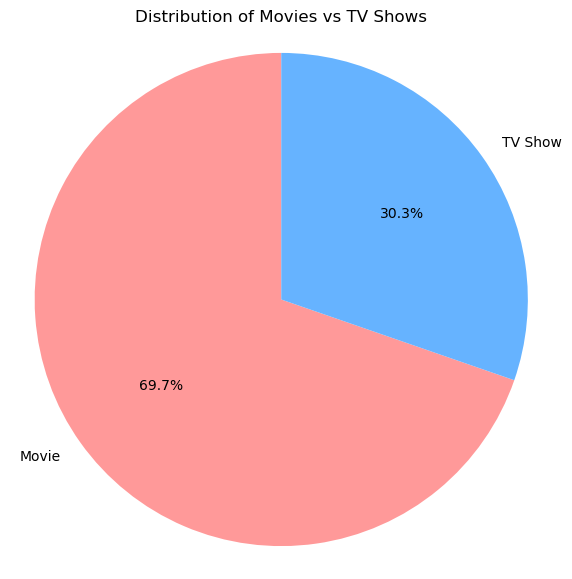

Most common type is: Movie
Number of Movies: 6126
Number of TV Shows: 2664


In [9]:
# implementation here
type_counts = netflix_df['type'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribution of Movies vs TV Shows')
plt.axis('equal')
plt.show()

print(f"Most common type is: {type_counts.idxmax()}")
print(f"Number of Movies: {type_counts.get('Movie', 0)}")
print(f"Number of TV Shows: {type_counts.get('TV Show', 0)}")

### Analysis of Content Types

As illustrated by the pie chart:

* **Dominant Category:** **Movies** clearly dominate the Netflix library, accounting for **69.7%** of the total content (6,126 titles).
* **TV Shows:** In contrast, **TV Shows** make up the remaining **30.3%** (2,664 titles) of the catalog.

### Q2. Time Trends(5pts)

- How has the number of titles added to Netflix changed over time?

Use the release time information from the dataset and count how many titles were added each year. Visualize the trend with a plot to show how Netflix's catalog has grown over time.

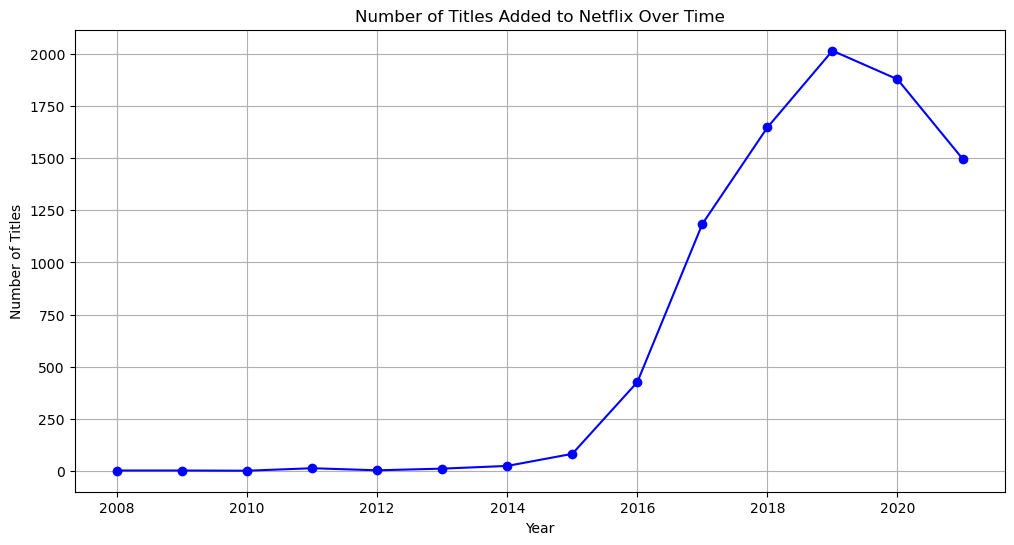

In [10]:
# implementation here
titles_per_year = netflix_df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(titles_per_year.index, titles_per_year.values, marker='o', linestyle='-', color='b')
plt.title('Number of Titles Added to Netflix Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

### Q3. Genre Analysis(5pts)

- What are the 10 most common genres on Netflix?

The `listed_in` column contains the genre information. But it can contain multiple genres, seperated by commas. Split these into individual genre values and count how often each one appears. Plot the top 10 genres in a chart and describe the plot in 1-2 sentences.

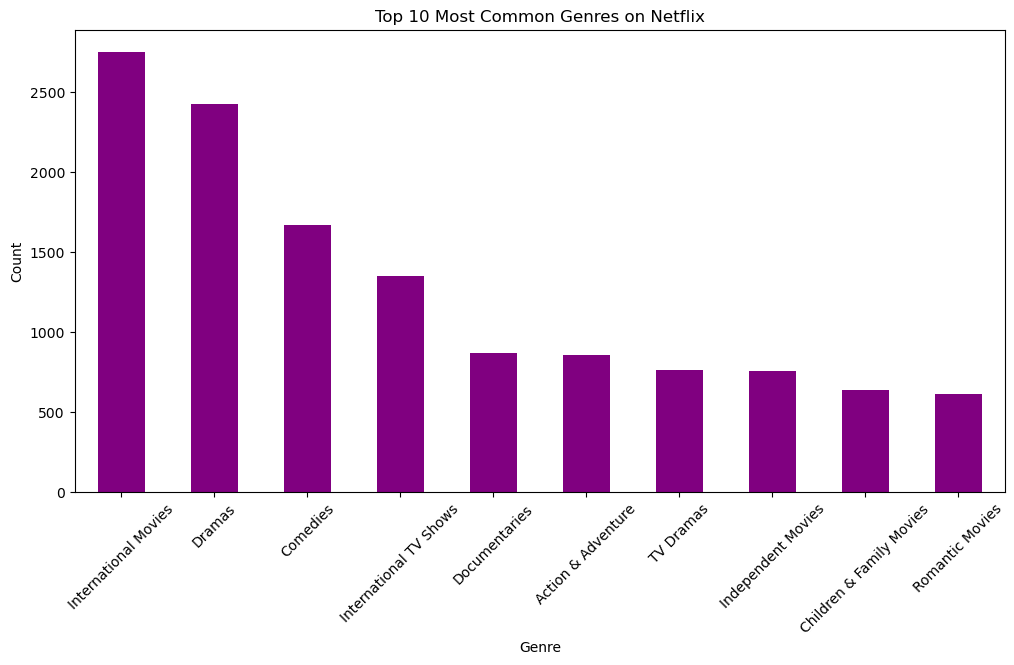

In [11]:
# implementation here
genres = netflix_df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12, 6))
top_genres.plot(kind='bar', color='purple')
plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Analysis of Top Genres

The bar chart highlights that **International Movies** and **Dramas** are the most dominant genres on Netflix, followed by Comedies. This distribution suggests a strong focus on global content and dramatic storytelling within the platform's library.

### Q4. Geographic Patterns(5pts)

- Which 10 countries have produced the most Netflix titles?

Some titles are produced by multiple countries (e.g., "France, Germany"). Ensure you account for all countries evenly by splitting the entries before counting. Show the top contributors using a chart.

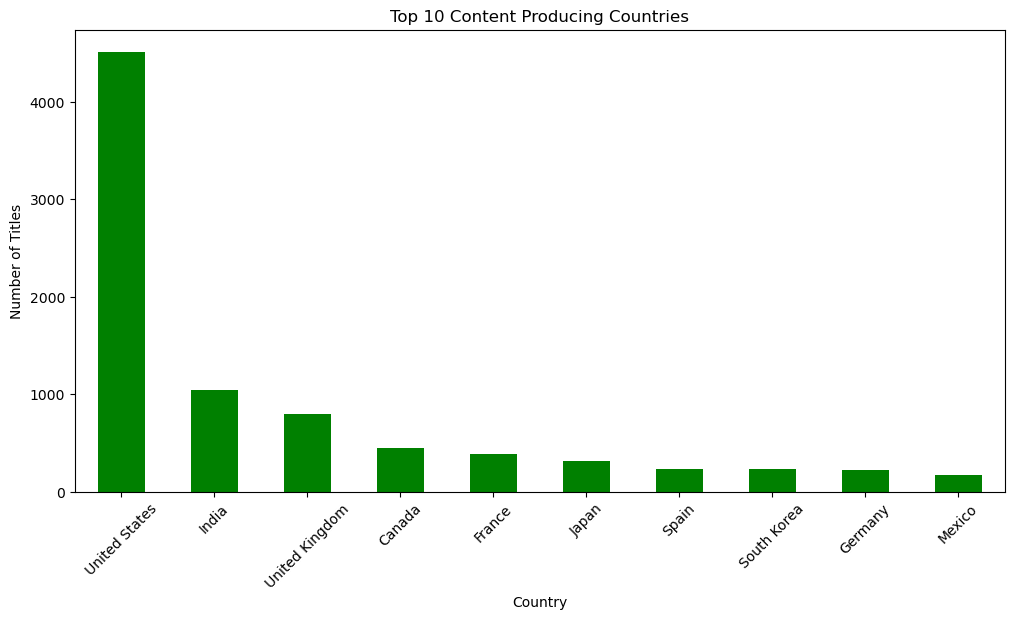

In [12]:
# implementation here
countries = netflix_df['country'].dropna().str.split(', ').explode()
top_countries = countries.value_counts().head(10)

plt.figure(figsize=(12, 6))
top_countries.plot(kind='bar', color='green')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

### Q5. Titles Added per Month(5pts)

- How many titles are added to Netflix in each month?

Use the release time information from the dataset. And report the added titles by "Month-Year" (e.g. "June-2016) then present it by a chart. You will manipulate the data to get that information. Then describe&comment on the chart with 1-2 sentences.

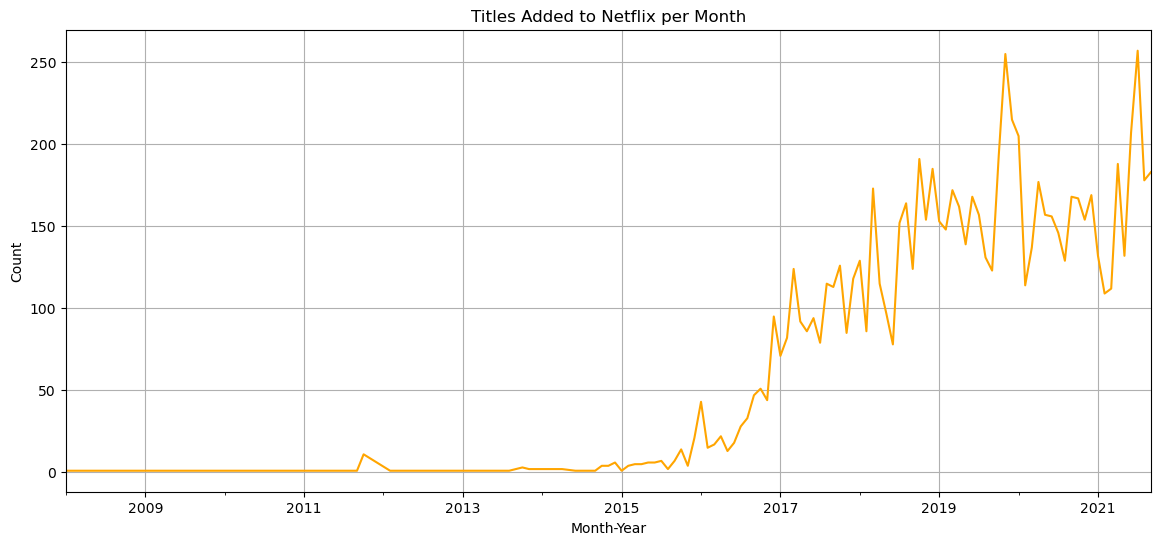

In [13]:
# implementation here
netflix_df['month_year'] = netflix_df['date_added'].dt.to_period('M')

monthly_counts = netflix_df['month_year'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
monthly_counts.plot(kind='line', color='orange')
plt.title('Titles Added to Netflix per Month')
plt.xlabel('Month-Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

### Analysis of Monthly Additions

The line chart demonstrates a dramatic increase in the number of titles added to Netflix starting around 2016. There is a clear upward trend with significant fluctuations, peaking in late 2019 and early 2020 where monthly additions exceeded 250 titles.

### Q6. Country Contribution Over Time(10pts)

- Identify the top 10 content producing countries.
- For the top 5 producing countries, how has the number of titles added changed year by year?

Identify the top 10 countries by counting total contents. Plot the results. Then identify the 5 countries with the most titles overall, and filter the dataset to just those. Group by both year added and country, and plot separate lines to compare their trends over time. Visualize the result and describe&comment on the chart with 1-2 sentences.

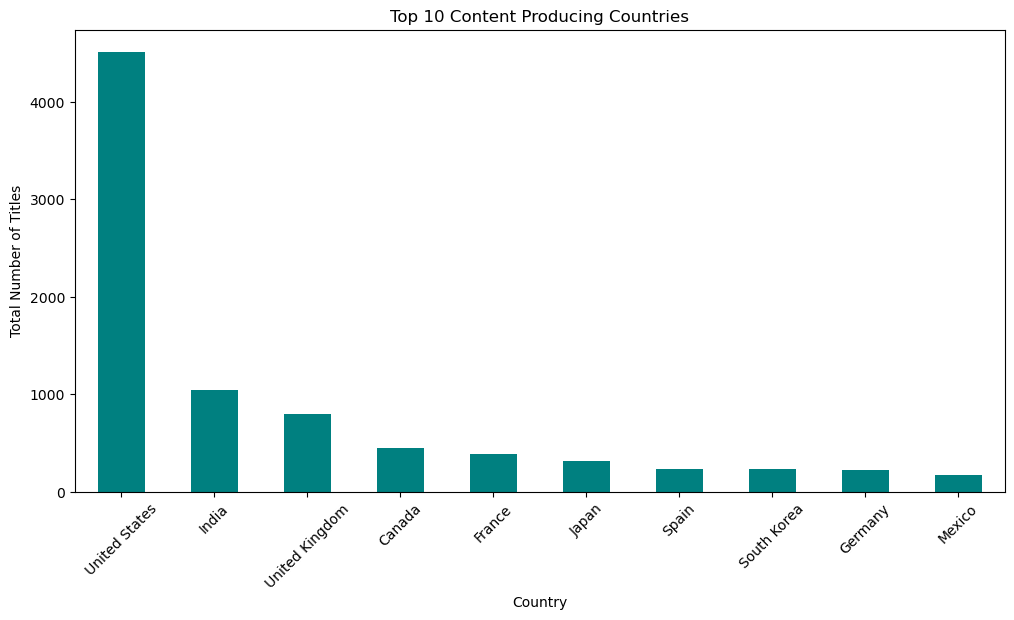

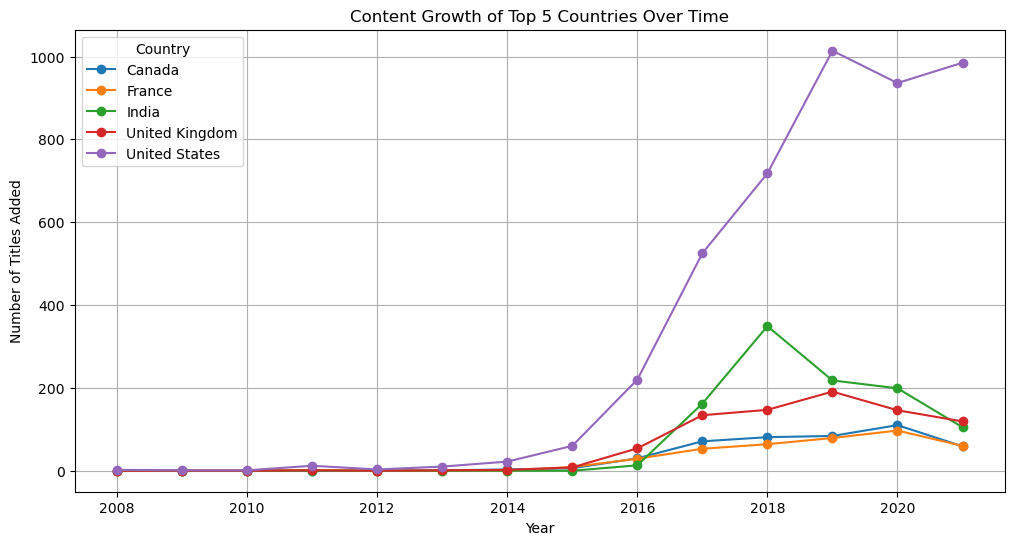

In [14]:
# implementation here
countries_exploded = netflix_df[['country', 'year_added']].dropna()
countries_exploded['country'] = countries_exploded['country'].str.split(', ')
countries_exploded = countries_exploded.explode('country')

top_10_countries = countries_exploded['country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_10_countries.plot(kind='bar', color='teal')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Total Number of Titles')
plt.xticks(rotation=45)
plt.show()

top_5_list = top_10_countries.head(5).index.tolist()
df_top5 = countries_exploded[countries_exploded['country'].isin(top_5_list)]

country_trends = df_top5.groupby(['year_added', 'country']).size().unstack().fillna(0)

country_trends.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Content Growth of Top 5 Countries Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.legend(title='Country')
plt.grid(True)
plt.show()

### Country Content Growth Analysis

The multi-line chart reveals that the **United States** is by far the largest contributor to Netflix, showing an exponential growth in content additions starting from 2015. **India** and the **United Kingdom** follow as distant seconds, also showing growth but at a much lower volume compared to the US.

### Q7. Average Movie Duration Over Time(5pts)

- How has the average movie duration changed over the years?

Focus only movies on the dataset (ignore TV Shows). Convert the duration column to a numeric value. And group by release year to compute the average movie length per year and visualize the trend.
Describe the chart with 1-2 sentences.

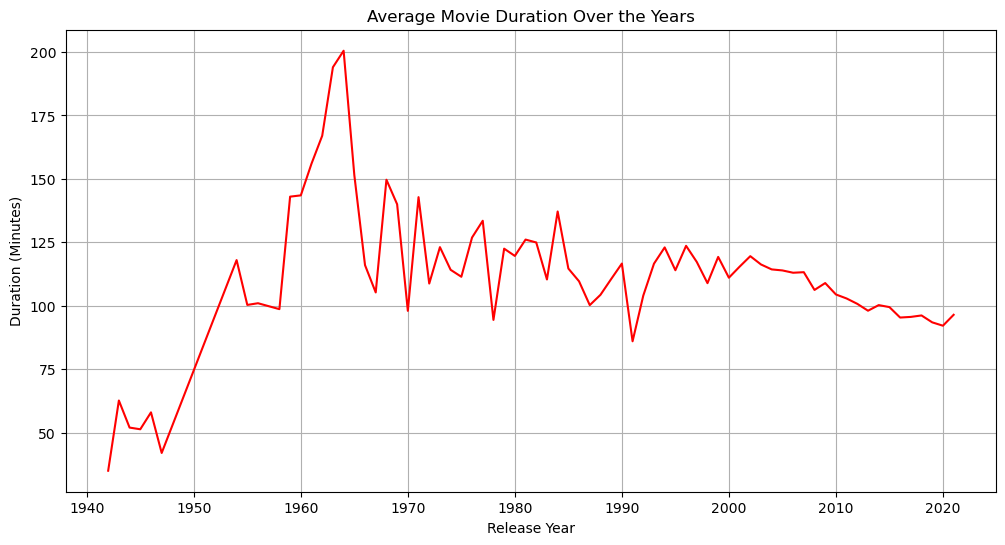

In [15]:
# implementation here
movies = netflix_df[netflix_df['type'] == 'Movie'].copy()
movies['duration_numeric'] = movies['duration'].str.replace(' min', '').astype(float)

avg_duration = movies.groupby('release_year')['duration_numeric'].mean()

plt.figure(figsize=(12, 6))
avg_duration.plot(color='red')
plt.title('Average Movie Duration Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Duration (Minutes)')
plt.grid(True)
plt.show()

### Average Movie Duration Trend

The line chart reveals interesting trends in movie runtimes:

* **Volatility in Early Years:** Between 1940 and 1970, the average duration is highly volatile with sharp spikes (reaching up to 200 minutes). This is likely due to the smaller number of movies from this era in the dataset, where a few long epics could skew the average.
* **Stabilization and Decline:** From the 2000s onwards, the trend stabilizes significantly. In the last decade (2010-2020), there is a noticeable gradual decline, with the average movie duration settling around **90-100 minutes**.

### Q8. TV Shows - Average Number of Seasons per Country(5pts)

- For each country, what is the average number of seasons in its TV Shows?

Focus only TV Shows on the dataset. The duration column contains the number of seasons (e.g. "3 Seasons"). Parse this information to a usable format. Then compute the average per country and visualize the top 10 countries. This gives insight about the countries tends to produce longer-running TV series.

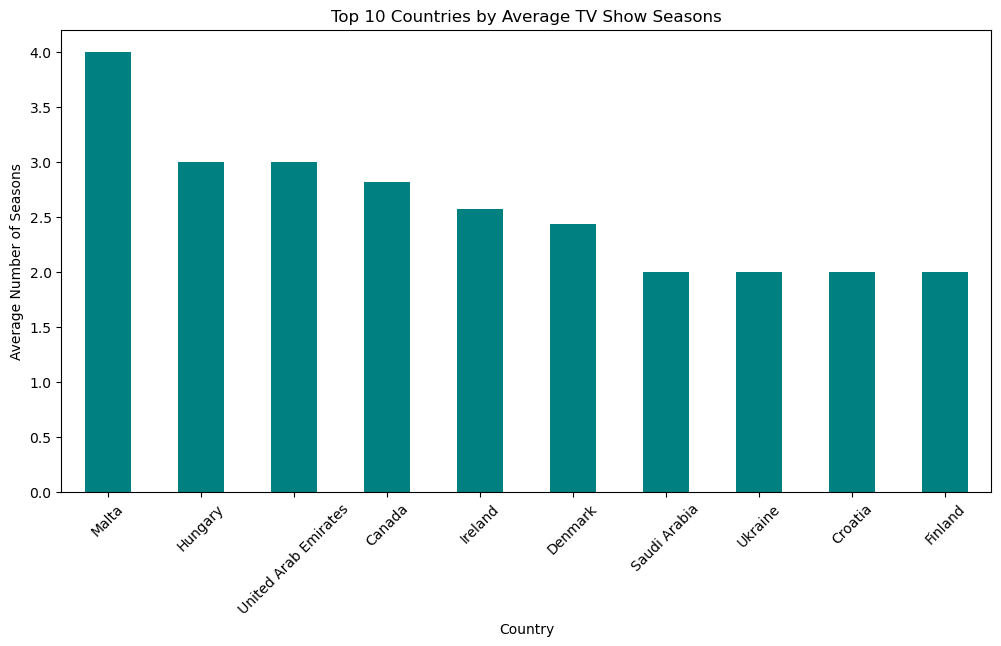

In [16]:
# implementation here
tv_shows = netflix_df[netflix_df['type'] == 'TV Show'].copy()
tv_shows['season_count'] = tv_shows['duration'].str.split(' ').str[0].astype(int)

tv_shows_exploded = tv_shows[['country', 'season_count']].dropna()
tv_shows_exploded['country'] = tv_shows_exploded['country'].str.split(', ')
tv_shows_exploded = tv_shows_exploded.explode('country')

avg_seasons = tv_shows_exploded.groupby('country')['season_count'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
avg_seasons.plot(kind='bar', color='teal')
plt.title('Top 10 Countries by Average TV Show Seasons')
plt.xlabel('Country')
plt.ylabel('Average Number of Seasons')
plt.xticks(rotation=45)
plt.show()

### Q9. Genre Popularity Shift Over Years(5pts)

- How has the popularity of the most popular 3 genres changed over time?

Choose 3 most popular genres (check Q3) and analyze how often titles of each genre were added per year. This will require splitting the multi-genre column, filtering by the chosen genres, and grouping by year. Plot a multi-line chart to show the trend on these genres over years.

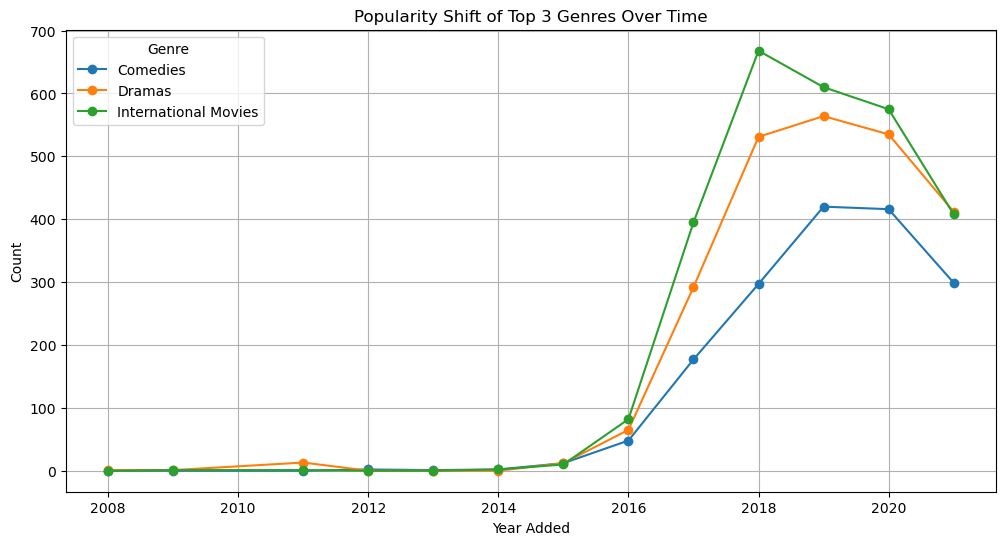

In [17]:
# implementation here
genres_df = netflix_df[['listed_in', 'year_added']].dropna()
genres_df['listed_in'] = genres_df['listed_in'].str.split(', ')
genres_exploded = genres_df.explode('listed_in')

top_3_genres = genres_exploded['listed_in'].value_counts().head(3).index.tolist()
df_top3 = genres_exploded[genres_exploded['listed_in'].isin(top_3_genres)]

genre_trends = df_top3.groupby(['year_added', 'listed_in']).size().unstack().fillna(0)

genre_trends.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Popularity Shift of Top 3 Genres Over Time')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.legend(title='Genre')
plt.grid(True)
plt.show()

# SUBMIT FORMAT

* **<-zip>**
  - **studentID_name_surname_hw2.ipynb**


# PLAGIARISM

All work on assignments must be done individually. You are encouraged to discuss the given assignments with your classmates, but these discussions should be carried out in an abstract way. That is, discussions related to a particular solution to a specific probem (either in actual code or in pseudocode) will not be tolerated. In short, turning in someone else’s work (including work available on the internet), in whole or in part, as your own will be considered as a violation of academic integrity. Please note that the former conditions also hold for the material attained using AI tools, including ChatGPT, GitHub Copilot, etc.